In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, PolynomialFeatures

from sklearn.compose import ColumnTransformer

# Pipeline
from sklearn.pipeline import Pipeline

# Klassifikation
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV

# Train/Test Split & Metriken
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Cross Validation und GridSearchCV
from sklearn.model_selection import KFold
from sklearn.metrics import make_scorer, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")

import warnings
warnings.filterwarnings("ignore")


In [ ]:
# Datensatz in Erste Teile vorbereitet laden Überblick
df = pd.read_csv('Marktkampagne_V2.csv')
df.head(10)

In [ ]:
df.columns

## GridSearchCV

Fitting 3 folds for each of 324 candidates, totalling 972 fits
Beste Parameter: {'classifier__estimator__max_depth': 5, 'classifier__estimator__max_features': None, 'classifier__estimator__min_samples_leaf': 4, 'classifier__estimator__min_samples_split': 2, 'classifier__estimator__n_estimators': 100}
                         F1_Score
Kampagne_1_Akzeptiert    0.473118
Kampagne_2_Akzeptiert    0.000000
Kampagne_3_Akzeptiert    0.354430
Kampagne_4_Akzeptiert    0.439560
Kampagne_5_Akzeptiert    0.534884
Antwort_Letzte_Kampagne  0.558442


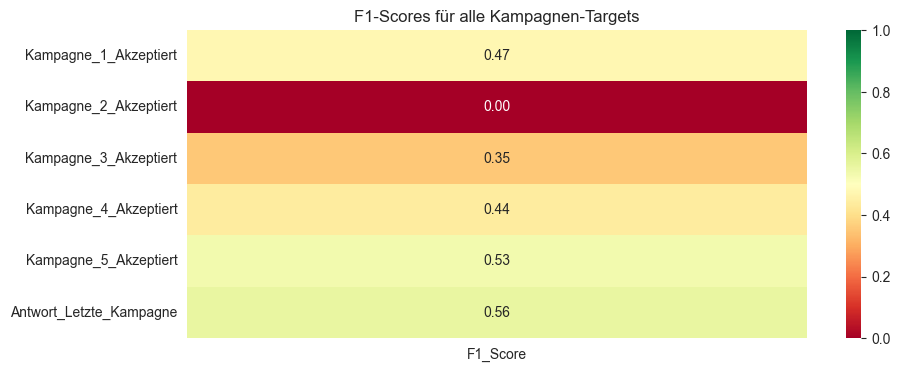

In [ ]:
# -----------------------------
# 1️⃣ Imports
# -----------------------------


from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score, make_scorer

# -----------------------------
# 2️⃣ Features & Targets
# -----------------------------
numerical_features = [
    'Alter', 'Einkommen', 'Gesamt_Kinder', 'Kundenbindungsdauer_Jahre', 
    'Letzter_Kauf_Tage', 'Ausgaben_Wein','Ausgaben_Fleisch','Ausgaben_Obst',
    'Ausgaben_Fisch','Ausgaben_Süßigkeiten','Ausgaben_Gold','Ausgaben_pro_Jahr',
    'Wein_Anteil','Anzahl_Rabattkäufe','Anzahl_Katalogkäufe','Anzahl_Ladeneinkäufe',
    'Anzahl_Webkäufe','Anzahl_WebBesuche_Monat'
]

categorical_features = ['Bildungsniveau', 'Familienstand']

targets = [
    'Kampagne_1_Akzeptiert', 'Kampagne_2_Akzeptiert', 
    'Kampagne_3_Akzeptiert', 'Kampagne_4_Akzeptiert', 
    'Kampagne_5_Akzeptiert', 'Antwort_Letzte_Kampagne'
]

X = df[numerical_features + categorical_features]
y = df[targets]  # 2D DataFrame für MultiOutput

# -----------------------------
# 3️⃣ Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 4️⃣ Transformer & Pipeline
# -----------------------------
transformer = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

pipeline = Pipeline([
    ('transformer', transformer),
    ('classifier', MultiOutputClassifier(
        RandomForestClassifier(class_weight='balanced', random_state=42)
    ))
])

# -----------------------------
# 5️⃣ Multi-Output F1 Scorer
# -----------------------------
def multioutput_f1(y_true, y_pred):
    scores = []
    for i in range(y_true.shape[1]):
        scores.append(f1_score(y_true.iloc[:, i], y_pred[:, i], average='binary'))
    return np.mean(scores)

f1_scorer = make_scorer(multioutput_f1)

# -----------------------------
# 6️⃣ GridSearchCV
# -----------------------------
param_grid = {
    'classifier__estimator__n_estimators': [100, 200, 300],
    'classifier__estimator__max_depth': [5, 8, 12, None],
    'classifier__estimator__min_samples_split': [2, 5, 10],
    'classifier__estimator__min_samples_leaf': [1, 2, 4],
    'classifier__estimator__max_features': ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=f1_scorer,
    cv=3,
    verbose=2,
    n_jobs=-1,
    refit=True
)

# -----------------------------
# 7️⃣ Fit GridSearchCV
# -----------------------------
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("Beste Parameter:", grid_search.best_params_)

# -----------------------------
# 8️⃣ Vorhersage & F1-Score Berechnung
# -----------------------------
y_pred = pd.DataFrame(best_model.predict(X_test), columns=targets)

f1_scores = {col: f1_score(y_test[col], y_pred[col], average='binary') for col in targets}
f1_df = pd.DataFrame.from_dict(f1_scores, orient='index', columns=['F1_Score'])
print(f1_df)

# -----------------------------
# 9️⃣ Heatmap der F1-Scores
# -----------------------------
plt.figure(figsize=(10, 4))
sns.heatmap(
    f1_df,
    annot=True,
    fmt=".2f",
    cmap='RdYlGn',
    vmin=0,
    vmax=1
)
plt.title('F1-Scores für alle Kampagnen-Targets')
plt.yticks(rotation=0)
plt.show()


## RandomizedSearchCV

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Beste Parameter: {'classifier__estimator__n_estimators': 200, 'classifier__estimator__min_samples_split': 10, 'classifier__estimator__min_samples_leaf': 4, 'classifier__estimator__max_features': 'sqrt', 'classifier__estimator__max_depth': 5}
                         F1_Score
Kampagne_1_Akzeptiert    0.450980
Kampagne_2_Akzeptiert    0.000000
Kampagne_3_Akzeptiert    0.388060
Kampagne_4_Akzeptiert    0.356436
Kampagne_5_Akzeptiert    0.533333
Antwort_Letzte_Kampagne  0.530612


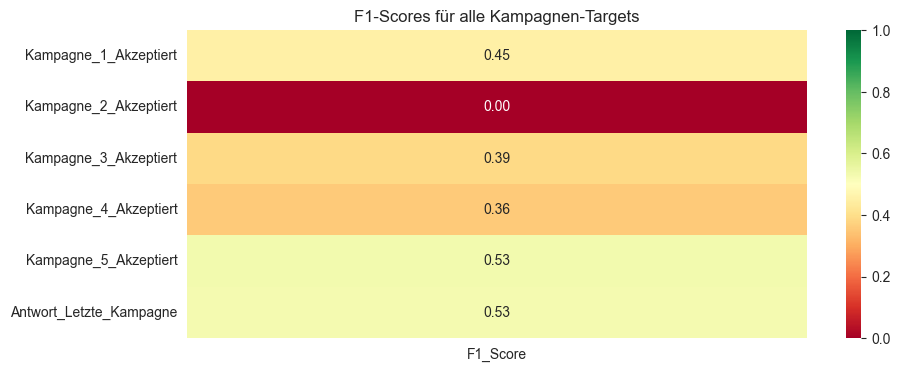

In [ ]:
# -----------------------------
# 1️⃣ Imports
# -----------------------------

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score, make_scorer

# -----------------------------
# 2️⃣ Features & Targets
# -----------------------------
numerical_features = [
    'Alter', 'Einkommen', 'Gesamt_Kinder', 'Kundenbindungsdauer_Jahre', 
    'Letzter_Kauf_Tage', 'Ausgaben_Wein','Ausgaben_Fleisch','Ausgaben_Obst',
    'Ausgaben_Fisch','Ausgaben_Süßigkeiten','Ausgaben_Gold','Ausgaben_pro_Jahr',
    'Wein_Anteil','Anzahl_Rabattkäufe','Anzahl_Katalogkäufe','Anzahl_Ladeneinkäufe',
    'Anzahl_Webkäufe','Anzahl_WebBesuche_Monat'
]

categorical_features = ['Bildungsniveau', 'Familienstand']

targets = [
    'Kampagne_1_Akzeptiert', 'Kampagne_2_Akzeptiert', 
    'Kampagne_3_Akzeptiert', 'Kampagne_4_Akzeptiert', 
    'Kampagne_5_Akzeptiert', 'Antwort_Letzte_Kampagne'
]

X = df[numerical_features + categorical_features]
y = df[targets]  # 2D DataFrame für MultiOutput

# -----------------------------
# 3️⃣ Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 4️⃣ Transformer & Pipeline
# -----------------------------
transformer = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

pipeline = Pipeline([
    ('transformer', transformer),
    ('classifier', MultiOutputClassifier(
        RandomForestClassifier(class_weight='balanced', random_state=42)
    ))
])

# -----------------------------
# 5️⃣ Multi-Output F1 Scorer
# -----------------------------
def multioutput_f1(y_true, y_pred):
    scores = []
    for i in range(y_true.shape[1]):
        scores.append(f1_score(y_true.iloc[:, i], y_pred[:, i], average='binary'))
    return np.mean(scores)

f1_scorer = make_scorer(multioutput_f1)

# -----------------------------
# 6️⃣ RandomizedSearchCV
# -----------------------------
param_dist = {
    'classifier__estimator__n_estimators': [100, 200, 300],
    'classifier__estimator__max_depth': [5, 8, 12, None],
    'classifier__estimator__min_samples_split': [2, 5, 10],
    'classifier__estimator__min_samples_leaf': [1, 2, 4],
    'classifier__estimator__max_features': ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring=f1_scorer,
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42,
    refit=True  # <- sehr wichtig für best_estimator_
)

# -----------------------------
# 7️⃣ Fit RandomizedSearchCV
# -----------------------------
random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_
print("Beste Parameter:", random_search.best_params_)

# -----------------------------
# 8️⃣ Vorhersage & F1-Score Berechnung
# -----------------------------
y_pred = pd.DataFrame(best_model.predict(X_test), columns=targets)

f1_scores = {col: f1_score(y_test[col], y_pred[col], average='binary') for col in targets}
f1_df = pd.DataFrame.from_dict(f1_scores, orient='index', columns=['F1_Score'])
print(f1_df)

# -----------------------------
# 9️⃣ Heatmap der F1-Scores
# -----------------------------
plt.figure(figsize=(10, 4))
sns.heatmap(
    f1_df,
    annot=True,
    fmt=".2f",
    cmap='RdYlGn',
    vmin=0,
    vmax=1
)
plt.title('F1-Scores für alle Kampagnen-Targets')
plt.yticks(rotation=0)
plt.show()


Hyperparametre optimisieren aber kein verbesserung fast gleiche F1 score mit die beiden RandomizedSearchCV und GridSearchCV